In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns 
import os 

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report,
                             confusion_matrix, 
                             accuracy_score, 
                             roc_auc_score, 
                             roc_curve,
                             precision_score,
                             recall_score,
                             precision_recall_curve,
                             f1_score) 
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [6]:
df= pd.read_csv('bankloan.csv')

In [7]:
df.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [8]:
df.tail()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [10]:
fig = px.pie(df, 
             names='Personal.Loan', 
             title='Personal Loan Distribution')
fig.show()

In [11]:
print("Negative Experience Count:", (df['Experience'] < 0).sum())

Negative Experience Count: 52


In [12]:
median_exp = df['Experience'].median()
df.loc[df['Experience'] < 0, 'Experience'] = median_exp

In [13]:
df.replace({'Personal.Loan': {0: 'No Loan', 1: 'Loan Approved'}},inplace=True)

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,No Loan,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,No Loan,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,No Loan,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,No Loan,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,No Loan,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,No Loan,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,No Loan,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,No Loan,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,No Loan,0,0,1,0


In [14]:
fig = px.scatter(
    df, 
    x='Income', 
    y='CCAvg', 
    color='Personal.Loan',
    title='Income vs. Credit Card Average Spend',
    labels={'Income': 'Annual Income ($k)', 'CCAvg': 'Monthly CC Spend ($k)', 'Personal.Loan': 'Status'},
    opacity=0.6
)


fig.show()

In [15]:
education_analysis = pd.crosstab(df['Education'], df['Personal.Loan'], normalize='index') * 100
print("Percentage of loan approval by Education Level:")
print(education_analysis)

Percentage of loan approval by Education Level:
Personal.Loan  Loan Approved    No Loan
Education                              
1                   4.437023  95.562977
2                  12.972202  87.027798
3                  13.657562  86.342438


In [16]:
cd_analysis = pd.crosstab(df['CD.Account'], df['Personal.Loan'], normalize='index') * 100
print("\nPercentage of loan approval by CD Account Ownership:")
print(cd_analysis)


Percentage of loan approval by CD Account Ownership:
Personal.Loan  Loan Approved    No Loan
CD.Account                             
0                   7.237122  92.762878
1                  46.357616  53.642384


In [17]:
fig_edu = px.histogram(
    df, 
    x='Education', 
    color='Personal.Loan', 
    barmode='group',
    barnorm='percent',
    title='Loan Approval Rate by Education Level',
    labels={'Education': 'Education Level (1: Undergrad, 2: Graduate, 3: Advanced)', 'percent': 'Percentage (%)', 'Personal.Loan': 'Status'}
)

fig_edu.show()

In [18]:
fig_cd = px.histogram(
    df, 
    x='CD.Account', 
    color='Personal.Loan', 
    barmode='group',
    barnorm='percent',
    title='Loan Approval Rate by CD Account Ownership',
    labels={'CD.Account': 'Has CD Account (0: No, 1: Yes)', 'percent': 'Percentage (%)', 'Personal.Loan': 'Status'}
)

fig_cd.show()

In [19]:
fig_mort = px.box(
    df, 
    x='Personal.Loan', 
    y='Mortgage',
    title='Mortgage Distribution by Loan Status',
    labels={'Personal.Loan': 'Status', 'Mortgage': 'Mortgage Value ($k)'}
)

fig_mort.show()

In [20]:
fig_age_exp = px.scatter(
    df, 
    x='Age', 
    y='Experience', 
    trendline='ols',
    title='Age vs. Experience Trendline',
    labels={'Age': 'Customer Age', 'Experience': 'Years of Experience'}
)
fig_age_exp.show()

In [21]:
df[(df['Age'] < 30) & (df['Experience'] == 20)][['Age', 'Experience']]

,Age,Experience
89,25,20
226,24,20
315,24,20
451,28,20
524,24,20
536,25,20
540,25,20
576,25,20
583,24,20
597,24,20


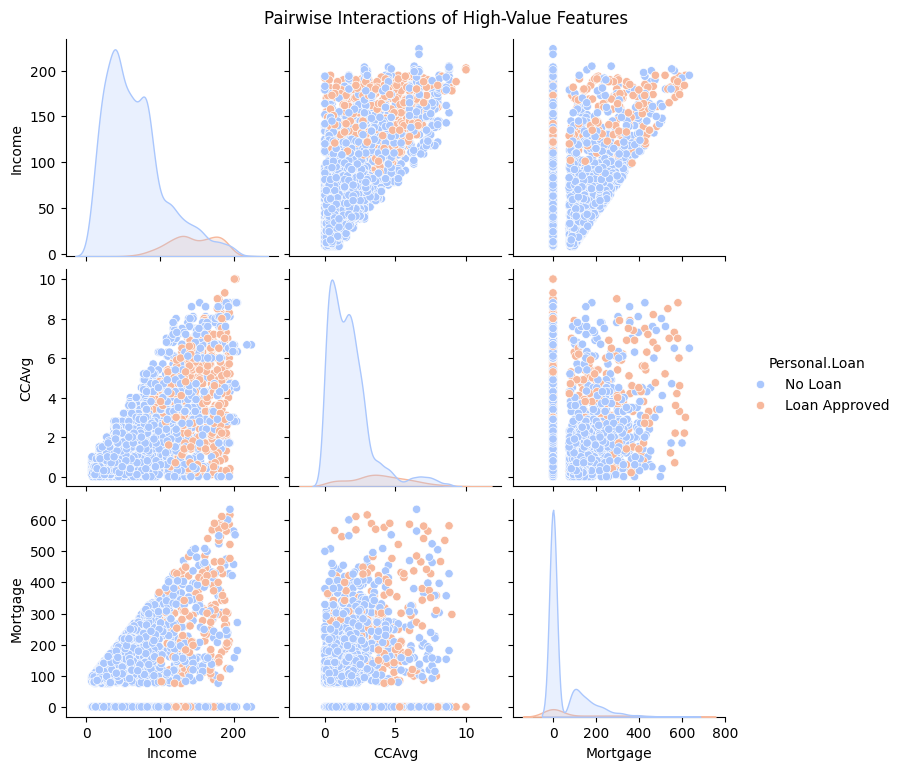

In [22]:
sns.pairplot(df, vars=['Income', 'CCAvg', 'Mortgage'], hue='Personal.Loan', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairwise Interactions of High-Value Features', y=1.02)
plt.show()

In [23]:
df= pd.read_csv('bankloan.csv')

In [24]:
X = df.drop(columns=['ID', 'ZIP.Code', 'Personal.Loan'])
y = df['Personal.Loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [26]:
ratio

np.float64(9.416666666666666)

In [27]:
ada_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', AdaBoostClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'))
])

In [28]:
ada_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__learning_rate': [0.01, 0.1, 1.0]
}

xgb_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3, 5, 6],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

In [29]:
import time
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Execute Fine-Tuning for AdaBoost & Track Time
print("Tuning AdaBoost Pipeline...")
start_ada = time.time()
ada_search = GridSearchCV(ada_pipeline, ada_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
ada_search.fit(X_train, y_train)
ada_time = time.time() - start_ada

Tuning AdaBoost Pipeline...


In [30]:
print("Tuning XGBoost Pipeline...")
start_xgb = time.time()
xgb_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_time = time.time() - start_xgb

Tuning XGBoost Pipeline...


In [31]:
best_ada = ada_search.best_estimator_
best_xgb = xgb_search.best_estimator_

print("\nModel tuning complete!")


Model tuning complete!


In [32]:
y_pred_ada = best_ada.predict(X_test)
y_prob_ada = best_ada.predict_proba(X_test)[:, 1]

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [33]:
metrics_summary = {
    'Evaluation Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Total Tuning Time (s)'],
    'AdaBoost Pipeline': [
        accuracy_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_ada),
        roc_auc_score(y_test, y_prob_ada),
        ada_time
    ],
    'XGBoost Pipeline': [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb),
        xgb_time
    ]
}

df_metrics = pd.DataFrame(metrics_summary).set_index('Evaluation Metric')
print("\n================ PROGRESS PERFORMANCE MATRIX ================")
print(df_metrics.round(4))


================ PROGRESS PERFORMANCE MATRIX ================
                       AdaBoost Pipeline  XGBoost Pipeline
Evaluation Metric                                         
Accuracy                          0.9660            0.9900
Precision                         0.8523            0.9216
Recall                            0.7812            0.9792
F1-Score                          0.8152            0.9495
ROC-AUC                           0.9841            0.9989
Total Tuning Time (s)            26.7118            9.1355


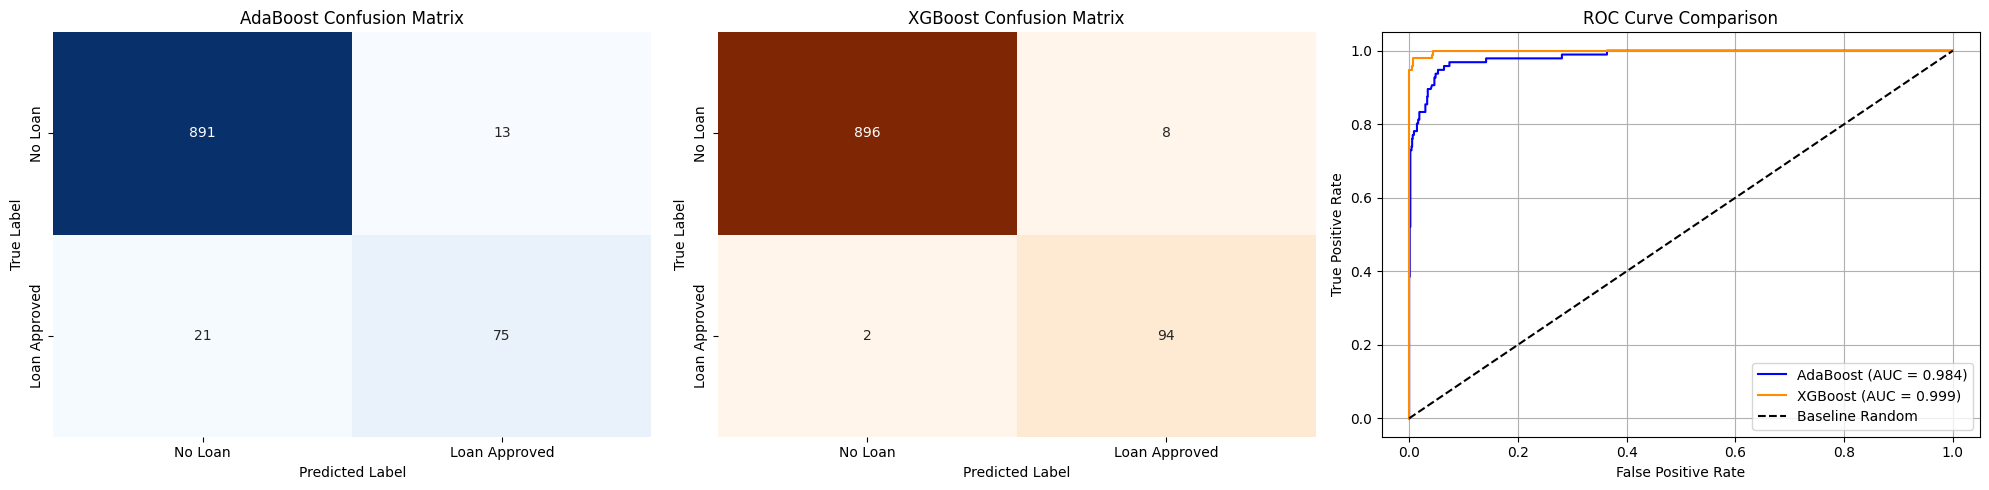

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: AdaBoost Confusion Matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('AdaBoost Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['No Loan', 'Loan Approved'])
axes[0].set_yticklabels(['No Loan', 'Loan Approved'])

# Plot 2: XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['No Loan', 'Loan Approved'])
axes[1].set_yticklabels(['No Loan', 'Loan Approved'])

# Plot 3: Overlaid ROC Curves
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[2].plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc_score(y_test, y_prob_ada):.3f})", color='blue')
axes[2].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})", color='darkorange')
axes[2].plot([0, 1], [0, 1], 'k--', label='Baseline Random')
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

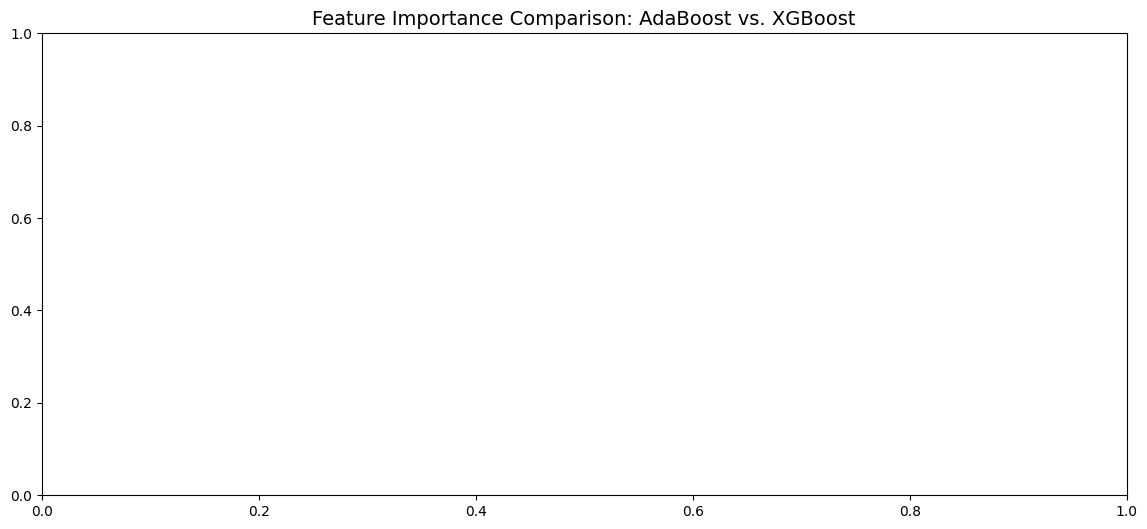

In [37]:

models = [ada_search.best_estimator_, xgb_search.best_estimator_]
model_names = ['AdaBoost', 'XGBoost']


plt.figure(figsize=(14, 6))
plt.title("Feature Importance Comparison: AdaBoost vs. XGBoost", fontsize=14)


width = 0.35 

for i, model in enumerate(models):
    importances = model.feature_importances_


    x_positions = np.arange(len(importances)) + (i * width)
    
    plt.bar(x_positions, importances, width=width, alpha=0.7, label=model_names[i])



plt.xticks(np.arange(len(importances)) + width/2, X_train.columns, rotation=45, ha='right')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()